<table style="width: 100%; border-collapse: collapse; border: none; background: #f8fafc; border-left: 6px solid #1e3a8a; border-radius: 8px; padding: 20px; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
  <tr style="border: none;">
    <td style="vertical-align: middle; border: none; padding: 15px 20px;">
      <h1 style="margin: 0; color: #0f172a; font-size: 2.1em; font-family: system-ui, -apple-system, sans-serif; font-weight: 800; letter-spacing: -0.02em;">
        Fundamentos del Aprendizaje por Refuerzo y MDPs 🎮
      </h1>
      <p style="margin: 6px 0 0 0; color: #1e3a8a; font-size: 1.15em; font-weight: 600; font-family: system-ui, -apple-system, sans-serif;">
        Especialización en Ciencia de Datos | Machine Learning
      </p>
      <p style="margin: 4px 0 0 0; color: #64748b; font-size: 0.95em; font-family: system-ui, -apple-system, sans-serif;">
        Universidad Santo Tomás — Seccional Tunja
      </p>
    </td>
    <td style="text-align: right; vertical-align: middle; border: none; padding: 15px 20px; width: 30%;">
      <span style="background: #1e3a8a; color: #ffffff; padding: 6px 14px; border-radius: 20px; font-size: 0.85em; font-weight: 700; display: inline-block; margin-bottom: 8px;">
        Módulo 06
      </span><br>
      <span style="color: #64748b; font-size: 0.85em;">Docente: Santiago A. Zúñiga M.</span><br>
      <a href="mailto:gestorvirtualcienciadatos@ustatunja.edu.co" style="color: #2563eb; font-size: 0.8em; text-decoration: none; font-weight: 500;">gestorvirtualcienciadatos@ustatunja.edu.co</a>
    </td>
  </tr>
</table>

<div align="center" style="margin-top: 15px; margin-bottom: 15px;">
  <a href="https://colab.research.google.com/github/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/blob/main/Machine%20Learning/06%20-%20Aprendizaje%20por%20Refuerzo/00_Fundamentos_RL_y_MDPs.ipynb" target="_parent">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" style="vertical-align: middle;"/>
  </a>
</div>

---
## Objetivos de Aprendizaje 🔎

Este cuaderno abre el **Módulo 06** y desarrolla las secciones **2.7 (*Reinforcement Learning*)** y **2.8.1 (*Markov Decision Processes*)** del Capítulo 2. En el [Módulo 00](../00%20-%20Introduccion%20al%20Machine%20Learning/01_Paradigmas_de_Aprendizaje.ipynb) el aprendizaje por refuerzo apareció solo como el tercer paradigma, con un **bandido multibrazo** $\varepsilon$-*greedy*: un problema con un único estado. Aquí damos el salto al **problema completo**: un agente que decide en **secuencia**, donde cada acción cambia el estado y las recompensas llegan **con retraso**. Seguimos el método del curso: **formular, implementar desde cero y verificar**.

Al terminar podrás:

1. **Describir** el bucle **agente–entorno** y la **hipótesis de la recompensa**, y diferenciar el refuerzo del aprendizaje supervisado.
2. **Calcular** el **retorno** $G_t$ con **factor de descuento** $\gamma$, deducir su recursión y justificar por qué descontamos.
3. **Definir** formalmente un **MDP** $(\mathcal S,\mathcal A,P,R,\gamma)$, la **política** $\pi$, la **propiedad de Markov** y la diferencia entre tareas **episódicas** y **continuas**.
4. **Construir desde cero** un MDP finito (un *FrozenLake* resbaladizo) con **matrices $P$ y $R$ explícitas** y comprobar que es un modelo de probabilidad válido.
5. **Simular** episodios y **estimar por Monte Carlo** el valor de una política aleatoria, **verificándolo** contra el cálculo exacto $(I-\gamma P_\pi)V=r_\pi$.
6. **Usar** la API de **Gymnasium** (`reset`, `step`, `terminated` frente a `truncated`) y **demostrar con `assert`** que tu entorno tiene las mismas probabilidades de transición que `FrozenLake-v1`.
7. **Explicar** el dilema **exploración–explotación** en el contexto de un MDP.

> 📍 **Dónde estamos:** Módulo 06, cuaderno 1 de 4. Después de las técnicas de [reducción de dimensionalidad (Módulo 05)](../05%20-%20Reduccion%20de%20Dimensionalidad/README.md), entramos al tercer bloque del Capítulo 2. Sigue [Funciones de valor y Q-learning](01_Funciones_de_Valor_y_Q_Learning.ipynb).

> 🔗 **Para no repetir:** el bandido multibrazo y la fórmula del *Q-learning* ya se presentaron en el [Módulo 00](../00%20-%20Introduccion%20al%20Machine%20Learning/01_Paradigmas_de_Aprendizaje.ipynb); aquí **no** se repiten, se **generalizan**. Del curso de [Introducción a la IA](../../Introduccion%20a%20la%20Inteligencia%20Artificial/04%20-%20Algoritmos%20de%20Busqueda/README.md) vienen la idea de **agente**, **estado** y **acción**; la diferencia es que allá el modelo del problema es **conocido y determinista** (búsqueda), y aquí el resultado de actuar es **incierto** y la solución es una **política**, no un camino.

---
## Recursos Recomendados 📚

### 📖 Libros de Referencia:
- *Hands-On Machine Learning with Scikit-Learn and PyTorch* — **Aurélien Géron** (O'Reilly, 2025). Cap. 19 (*Reinforcement Learning*): *What Is Reinforcement Learning?*, *Introduction to the Gymnasium Library*, *Evaluating Actions: The Credit Assignment Problem* y *Markov Decision Processes* (disponible en `Machine Learning/Libros/`; capítulo verificado contra el PDF).
- *Reinforcement Learning: An Introduction* — **Richard S. Sutton & Andrew G. Barto** (MIT Press, 2.ª ed., 2018). Cap. 1 (*Introduction*), Cap. 2 (*Multi-armed Bandits*) y Cap. 3 (*Finite Markov Decision Processes*). Disponible en línea de forma gratuita en el sitio de los autores *(citado de memoria, verificar)*. Es la referencia estándar: la notación de este módulo ($G_t$, $v_\pi$, $q_\pi$) es la suya.
- Bellman, R. (1957), *A Markovian Decision Process*, **Journal of Mathematics and Mechanics** 6(5): 679–684 (citado en el capítulo de Géron; los procesos de decisión de Markov se atribuyen a Bellman en los años 50).
- Russell, S. & Norvig, P. (2020), *Artificial Intelligence: A Modern Approach*, 4.ª ed., Cap. 17 (*Making Complex Decisions*): MDP y el «mundo 4×3» que usaremos en el cuaderno 02 *(citado de memoria, verificar)*.
- Mnih, V. et al. (2015), *Human-level control through deep reinforcement learning*, **Nature** 518: 529–533 (citado en el capítulo de Géron): el trabajo que impulsó el RL profundo (cuaderno 03).

### 🌐 Documentación y Recursos Online:
- [Gymnasium: *Basic Usage*](https://gymnasium.farama.org/introduction/basic_usage/) · [Gymnasium: *FrozenLake*](https://gymnasium.farama.org/environments/toy_text/frozen_lake/)
- [Sutton & Barto, *Reinforcement Learning: An Introduction* (2.ª ed.)](http://incompleteideas.net/book/the-book-2nd.html)

---
## 1. El Bucle Agente–Entorno y la Hipótesis de la Recompensa 🔄

En **aprendizaje supervisado** alguien nos da pares $(x,y)$ con la respuesta correcta. En **aprendizaje por refuerzo (RL)** no hay profesor ni respuestas: un **agente** actúa en un **entorno**, observa las consecuencias y recibe una **recompensa** escalar que solo le dice *qué tan bien le fue*, nunca *qué debió hacer*.



En cada paso discreto $t=0,1,2,\dots$ ocurre la misma secuencia: el agente **observa** $s_t$, **elige** $a_t$, y el entorno responde con $r_{t+1}$ y $s_{t+1}$. La interacción produce una **trayectoria** (o *rollout*)

$$s_0,\;a_0,\;r_1,\;s_1,\;a_1,\;r_2,\;s_2,\;\dots$$

**Hipótesis de la recompensa** (Sutton & Barto): todo lo que entendemos por «meta» o «propósito» puede formularse como **maximizar el valor esperado de la suma acumulada de una señal escalar** (la recompensa). Es una hipótesis de **modelado**, no un teorema: *diseñar la recompensa es parte del problema* (una recompensa mal diseñada produce agentes que «hacen trampa» cumpliendo la letra y no el espíritu).

### Qué hace distinto al refuerzo

| Aspecto | Supervisado | Por refuerzo |
|---|---|---|
| **Señal** | Respuesta correcta por ejemplo (*instructiva*) | Recompensa escalar (*evaluativa*): «bien/mal», no «qué hacer» |
| **Datos** | Conjunto fijo, ejemplos (casi) independientes | **Los genera el propio agente**: sus decisiones determinan qué ve |
| **Retroalimentación** | Inmediata | **Retrasada**: el error de hoy se paga dentro de muchos pasos (*credit assignment*) |
| **Dilema** | Sobreajuste/subajuste | **Exploración vs. explotación** |
| **Objetivo** | Minimizar el error de predicción | Maximizar el **retorno** esperado |

Los cuatro ingredientes de un sistema de RL (Sutton & Barto, cap. 1): una **política** (cómo decide el agente), una **señal de recompensa** (la meta), una **función de valor** (qué tan buena es una situación *a largo plazo*) y, opcionalmente, un **modelo** del entorno (para planificar). Los métodos que **no** usan un modelo se llaman ***model-free***; los que sí, ***model-based***. En este módulo veremos primero el caso donde **conocemos el modelo** (programación dinámica, cuaderno 01) y luego los que **aprenden sin conocerlo**.

In [ ]:
# ============================================================
# Configuracion inicial
# ============================================================
# !pip install -q gymnasium
# (numpy, pandas, matplotlib y seaborn vienen preinstalados en Google Colab; este cuaderno no necesita PyTorch)

import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gymnasium as gym

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (9, 5)
PALETA = ["#2563eb", "#dc2626", "#16a34a", "#f59e0b", "#7c3aed", "#0891b2", "#db2777", "#65a30d", "#78350f", "#475569"]
print(f"NumPy {np.__version__} | Gymnasium {gym.__version__}  (API moderna: reset() -> (obs, info); step() -> 5 valores)")

---
## 2. El Retorno y el Factor de Descuento $\gamma$ 💰

El agente no maximiza la recompensa **inmediata**, sino el **retorno**: la suma de las recompensas futuras, **descontadas**,

$$G_t=r_{t+1}+\gamma\,r_{t+2}+\gamma^2 r_{t+3}+\cdots=\sum_{k=0}^{\infty}\gamma^{k}\,r_{t+k+1},\qquad \gamma\in[0,1].$$

**Recursión fundamental.** Sacando $\gamma$ factor común de todo salvo el primer término:

$$G_t=r_{t+1}+\gamma\big(r_{t+2}+\gamma r_{t+3}+\cdots\big)=r_{t+1}+\gamma\,G_{t+1}.$$

Esta identidad es **la semilla de todo el módulo**: las ecuaciones de Bellman (cuaderno 01) son su esperanza, y el *bootstrapping* de TD y Q-learning la usa para estimar el retorno sin esperar al final del episodio.

### Tareas episódicas y continuas

- **Episódicas**: la interacción se divide en **episodios** que terminan en un estado **terminal** (ganar, caer en un hoyo, agotar el tiempo). El retorno es una suma finita y se puede usar $\gamma=1$.
- **Continuas**: no hay final natural (control de un termostato, trading). Con $\gamma=1$ la suma podría diverger; con $\gamma<1$ y recompensas acotadas $|r|\le r_{\max}$ queda **acotada**: $|G_t|\le r_{\max}/(1-\gamma)$ (serie geométrica).

### ¿Por qué descontar?

1. **Matemática**: garantiza que el retorno sea finito en tareas continuas.
2. **Incertidumbre**: el futuro lejano es menos predecible; una recompensa hoy es más segura que una promesa.
3. **Preferencia temporal**: preferimos lo pronto (el dinero rinde interés).
4. **Efecto práctico**: $\gamma$ fija un **horizonte efectivo** $\approx 1/(1-\gamma)$ pasos: con $\gamma=0.9$ el agente «mira» ~10 pasos; con $\gamma=0.99$, ~100. Un $\gamma$ muy bajo vuelve al agente **miope**; uno muy alto hace el aprendizaje lento e inestable.

In [ ]:
# ============================================================
# 2. El retorno: suma directa, recursion hacia atras y efecto de gamma
# ============================================================
def retorno(recompensas, gamma):
    """G_0 = sum_k gamma^k r_{k+1}, por suma directa."""
    return sum(gamma ** k * r for k, r in enumerate(recompensas))

def retornos_hacia_atras(recompensas, gamma):
    """G_t para todo t con la recursion G_t = r_{t+1} + gamma * G_{t+1}, recorriendo el episodio al reves (O(T))."""
    G = np.zeros(len(recompensas)); acumulado = 0.0
    for t in range(len(recompensas) - 1, -1, -1):
        acumulado = recompensas[t] + gamma * acumulado
        G[t] = acumulado
    return G

# Un episodio de 7 pasos: pequena perdida, un premio mediano y uno grande al final
recompensas = [0, 0, -1, 0, 5, 0, 10]
G = retornos_hacia_atras(recompensas, 0.9)
assert np.isclose(G[0], retorno(recompensas, 0.9))                                   # recursion == suma directa
assert all(np.isclose(G[t], retorno(recompensas[t:], 0.9)) for t in range(len(recompensas)))   # tambien para cada t
assert np.isclose(G[0], recompensas[0] + 0.9 * G[1])                                  # G_t = r_{t+1} + gamma G_{t+1}

# Recompensa constante r: serie geometrica finita y cota r / (1 - gamma) en tareas continuas
r, g = 2.0, 0.9
assert np.isclose(retorno([r] * 50, g), r * (1 - g ** 50) / (1 - g))
assert retorno([r] * 2000, g) <= r / (1 - g) + 1e-9 and retorno([r] * 200, g) < r / (1 - g) and np.isclose(retorno([r] * 2000, g), r / (1 - g))
print(f"Retornos G_t (gamma = 0.9) del episodio de ejemplo: {np.round(G, 3)}")
print(f"Con recompensa constante r = {r} y gamma = {g}: G -> r/(1-gamma) = {r / (1 - g):.1f}  (horizonte efectivo ~ {1 / (1 - g):.0f} pasos)")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
k = np.arange(0, 60)
for gam, color in zip([0.5, 0.9, 0.99], [PALETA[1], PALETA[0], PALETA[2]]):
    axes[0].plot(k, gam ** k, color=color, lw=2.5, label=rf"$\gamma$ = {gam}  (horizonte ~ {1 / (1 - gam):.0f})")
axes[0].set_xlabel("Pasos hacia el futuro $k$"); axes[0].set_ylabel(r"Peso de la recompensa: $\gamma^k$")
axes[0].set_title("Cuánto pesa una recompensa que llega dentro de $k$ pasos", fontweight="bold", fontsize=10); axes[0].legend(fontsize=9)
gammas = np.linspace(0, 1, 101)
axes[1].plot(gammas, [retorno(recompensas, gm) for gm in gammas], color=PALETA[4], lw=2.5)
axes[1].axvline(0.9, color="black", ls=":", label=r"$\gamma$ = 0.9"); axes[1].legend(fontsize=9)
axes[1].set_xlabel(r"Factor de descuento $\gamma$"); axes[1].set_ylabel(r"Retorno $G_0$ del episodio de ejemplo")
axes[1].set_title(r"$\gamma=0$: solo cuenta lo inmediato (miope); $\gamma=1$: todo cuenta igual", fontweight="bold", fontsize=10)
plt.tight_layout(); plt.show()

---
##### 🛠️ Práctica 1: Retornos a mano: ¿cuánta paciencia necesita este agente?

Un agente recorre un episodio de cinco pasos: los cuatro primeros **cuestan 1** punto cada uno y el último da un **premio de 20**. Con las funciones `retorno(recompensas, gamma)` y `retornos_hacia_atras(recompensas, gamma)` del §2:

1. Define `rec_prac = [-1, -1, -1, -1, 20]` y calcula $G_0$ con `retorno` para $\gamma\in\{0.5,\,0.8,\,0.9,\,0.99\}$; guarda el resultado en un diccionario `G0_por_gamma` (clave = $\gamma$).
2. Recorre la rejilla `np.linspace(0, 1, 101)` y guarda en `gamma_min` el **menor** $\gamma$ con $G_0>0$ (a partir de ahí el premio *compensa* los costos).
3. Verifica con `assert` que `retornos_hacia_atras(rec_prac, g)[0]` coincide con `G0_por_gamma[g]` para cada $\gamma$, que $G_0<0$ con $\gamma=0.5$ y $G_0>0$ con $\gamma=0.9$, y que `gamma_min` queda entre $0.5$ y $0.6$.

In [ ]:
# Escribe tu código aquí

# rec_prac = [-1, -1, -1, -1, 20]
# G0_por_gamma = {g: retorno(rec_prac, g) for g in [0.5, 0.8, 0.9, 0.99]}
# gamma_min = ...   # el primero de np.linspace(0, 1, 101) cuyo retorno sea > 0
# (comprueba con retornos_hacia_atras que G[0] == retorno(...) y con assert lo pedido)


<details>
<summary><b>💡 Haz clic aquí para ver la solución guiada...</b></summary>

```python
rec_prac = [-1, -1, -1, -1, 20]          # cuatro pasos que cuestan 1 y un premio de 20 al final

G0_por_gamma = {g: retorno(rec_prac, g) for g in [0.5, 0.8, 0.9, 0.99]}
for g, G0 in G0_por_gamma.items():
    print(f"gamma = {g:<4}: G_0 = {G0:7.3f}")

# Menor gamma de la rejilla con el que el premio compensa los costos (G_0 > 0)
gamma_min = next(g for g in np.linspace(0, 1, 101) if retorno(rec_prac, g) > 0)
print(f"\nMenor gamma de la rejilla con G_0 > 0: {gamma_min:.2f}")

# La recursion hacia atras da el mismo G_0 que la suma directa
for g in G0_por_gamma:
    assert np.isclose(retornos_hacia_atras(rec_prac, g)[0], G0_por_gamma[g])
assert G0_por_gamma[0.5] < 0 < G0_por_gamma[0.9]
assert 0.5 < gamma_min < 0.6
print("Con poca paciencia (gamma bajo) el agente solo 've' los costos y nunca intentaria llegar al premio.")
```
</details>

---


---
## 3. Política, Propiedad de Markov y la Definición de un MDP 🧩

### 3.1 La política

La **política** $\pi$ es la regla de decisión del agente. Puede ser **determinista**, $a=\pi(s)$, o **estocástica**, $\pi(a\mid s)=\Pr(a_t=a\mid s_t=s)$ (la forma general; la determinista es un caso particular). **Aprender en RL = encontrar una buena política.**

### 3.2 La propiedad de Markov

Un estado $s_t$ tiene la **propiedad de Markov** si **resume todo lo relevante del pasado** para predecir el futuro:

$$\Pr(s_{t+1},r_{t+1}\mid s_t,a_t,\;s_{t-1},a_{t-1},\dots,s_0)\;=\;\Pr(s_{t+1},r_{t+1}\mid s_t,a_t).$$

Es una propiedad **del estado** (de cómo lo definimos), no del mundo: si en un videojuego la observación es **una sola imagen**, no sabemos hacia dónde se mueve la pelota (falta la velocidad) y el proceso **no** es Markov respecto a esa observación; apilar los últimos 4 *frames* (como hicieron Mnih et al., 2015) **restaura** la propiedad. Cuando el agente no ve el estado completo hablamos de un MDP *parcialmente observable* (POMDP), que no trataremos aquí.

### 3.3 Definición de un MDP finito

Un **proceso de decisión de Markov (MDP)** finito es la tupla $(\mathcal S,\mathcal A,P,R,\gamma)$:

| Símbolo | Significado |
|---|---|
| $\mathcal S$ | Conjunto **finito** de estados |
| $\mathcal A$ | Conjunto finito de acciones |
| $P(s'\mid s,a)$ | **Dinámica**: probabilidad de pasar a $s'$ tras hacer $a$ en $s$ ($\sum_{s'}P(s'\mid s,a)=1$) |
| $R(s,a,s')$ | Recompensa de esa transición; su esperanza es $r(s,a)=\sum_{s'}P(s'\mid s,a)\,R(s,a,s')$ |
| $\gamma$ | Factor de descuento |

Fijada una política $\pi$, el MDP se convierte en una **cadena de Markov** con matriz de transición y vector de recompensas

$$P_\pi(s'\mid s)=\sum_a\pi(a\mid s)\,P(s'\mid s,a),\qquad r_\pi(s)=\sum_a\pi(a\mid s)\,r(s,a).$$

Estas dos cantidades son todo lo que necesitamos para **evaluar** una política **exactamente** (§6). El **objetivo** del RL es hallar $\pi$ que maximice el retorno esperado desde cualquier estado.

### 3.4 Exploración frente a explotación

Como el agente genera sus propios datos, enfrenta un dilema: **explotar** lo que ya cree mejor (ganar ahora) o **explorar** acciones poco probadas (quizá hay algo mejor). Sin explorar puede quedar atrapado en una política mediocre; explorando de más desperdicia recompensa. En el bandido del [Módulo 00](../00%20-%20Introduccion%20al%20Machine%20Learning/01_Paradigmas_de_Aprendizaje.ipynb) lo vimos con $\varepsilon$-*greedy*; en un MDP el dilema es **más difícil**, porque explorar un estado hoy puede revelar recompensas solo varios pasos después. Lo retomaremos con Q-learning en el cuaderno 01.

---
## 4. Construir un MDP desde Cero: *FrozenLake* Resbaladizo 🧊

Nuestro entorno de trabajo es el clásico ***FrozenLake***: un lago congelado de $4\times4$ casillas con la forma

```
S F F F        S = inicio (Start)         F = hielo firme (Frozen)
F H F H        H = hoyo (Hole): termina   G = meta (Goal): termina con recompensa +1
F F F H
H F F G
```

El agente se mueve con 4 acciones (0 = izquierda, 1 = abajo, 2 = derecha, 3 = arriba). El hielo es **resbaladizo**: la acción elegida se ejecuta con probabilidad $1/3$, y con probabilidad $1/3$ cada una el agente se desliza hacia **cualquiera de las dos direcciones perpendiculares**. Chocar con el borde deja al agente donde está. La recompensa es $+1$ al **entrar** en la meta y $0$ en cualquier otro caso; $\mathrm{H}$ y $\mathrm{G}$ son **terminales** (los modelamos como estados **absorbentes** con recompensa $0$ a partir de ahí).

Lo construimos como un **MDP explícito**: un tensor `P[s, a, s']` de $16\times4\times16$ y otro `R[s, a, s']`. Con esto **tenemos el modelo completo** y podremos calcular **cantidades exactas** para verificar todo lo que luego estimemos por simulación.

In [ ]:
# ============================================================
# Un MDP finito DESDE CERO: tensores P[s, a, s'] y R[s, a, s']
# ============================================================
MAPAS = {
    "4x4": ["SFFF", "FHFH", "FFFH", "HFFG"],
    "8x8": ["SFFFFFFF", "FFFFFFFF", "FFFHFFFF", "FFFFFHFF", "FFFHFFFF", "FHHFFFHF", "FHFFHFHF", "FFFHFFFG"],
}
MOV = {0: (0, -1), 1: (1, 0), 2: (0, 1), 3: (-1, 0)}      # 0 = Izquierda, 1 = Abajo, 2 = Derecha, 3 = Arriba (convencion de Gymnasium)
NOMBRE_ACCION = {0: "Izquierda", 1: "Abajo", 2: "Derecha", 3: "Arriba"}


class MDP:
    """MDP finito (S, A, P, R, gamma) con estado inicial fijo y estados terminales absorbentes.

    P[s, a, s2] = probabilidad de pasar a s2 tras hacer a en s;  R[s, a, s2] = recompensa de esa transicion.
    """
    def __init__(self, P, R, gamma, s0, terminales):
        self.P, self.R, self.gamma, self.s0 = P, R, gamma, s0
        self.terminales = np.asarray(terminales, dtype=bool)
        self.nS, self.nA = P.shape[0], P.shape[1]
        self.r = (P * R).sum(axis=2)                            # r(s, a) = E[R | s, a]
        self.cdf = np.cumsum(P, axis=2); self.cdf[..., -1] = 1.0   # para muestrear s2 con una sola uniforme

    def reset(self):
        return self.s0

    def step(self, s, a, rng):
        """Muestrea (s2, recompensa, terminado) segun la dinamica del MDP."""
        s2 = min(int(np.searchsorted(self.cdf[s, a], rng.random(), side="right")), self.nS - 1)
        return s2, self.R[s, a, s2], bool(self.terminales[s2])


def frozenlake(mapa="4x4", resbaladizo=True, gamma=0.99):
    """Construye FrozenLake como MDP explicito. Resbaladizo: la accion elegida ocurre con prob. 1/3 y con 1/3 cada
    una de las dos direcciones perpendiculares. Chocar con el borde = quedarse. H y G son terminales; recompensa 1 al entrar a G."""
    filas = MAPAS[mapa]; n = len(filas); nS = n * n
    P = np.zeros((nS, 4, nS)); R = np.zeros((nS, 4, nS)); term = np.zeros(nS, dtype=bool)
    for f in range(n):
        for c in range(n):
            s = f * n + c
            if filas[f][c] in "HG":                              # terminal absorbente: se queda y no da mas recompensa
                term[s] = True; P[s, :, s] = 1.0; continue
            for a in range(4):
                direcciones = [(a - 1) % 4, a, (a + 1) % 4] if resbaladizo else [a]
                for d in direcciones:
                    f2 = min(max(f + MOV[d][0], 0), n - 1); c2 = min(max(c + MOV[d][1], 0), n - 1)
                    s2 = f2 * n + c2
                    P[s, a, s2] += 1.0 / len(direcciones)
                    R[s, a, s2] = float(filas[f2][c2] == "G")
    return MDP(P, R, gamma, 0, term)


def evaluar_exacto(mdp, pi, gamma=None):
    """V^pi exacto resolviendo (I - gamma P_pi) V = r_pi. pi: matriz (nS, nA). V(terminal) = 0."""
    g = mdp.gamma if gamma is None else gamma
    Ppi = np.einsum("sa,sat->st", pi, mdp.P); rpi = (pi * mdp.r).sum(axis=1)
    Ppi[mdp.terminales] = 0.0; rpi[mdp.terminales] = 0.0       # el valor de un estado terminal es 0
    return np.linalg.solve(np.eye(mdp.nS) - g * Ppi, rpi)

# ------------------------------------------------------------
# Construccion y verificaciones del modelo
# ------------------------------------------------------------
mdp = frozenlake("4x4", resbaladizo=True, gamma=0.99)
print(f"|S| = {mdp.nS}, |A| = {mdp.nA}, gamma = {mdp.gamma}, estado inicial = {mdp.s0}, terminales = {np.flatnonzero(mdp.terminales).tolist()}")
print("Forma de P:", mdp.P.shape, "| Forma de R:", mdp.R.shape)

assert mdp.P.shape == (16, 4, 16) and mdp.R.shape == (16, 4, 16)
assert np.allclose(mdp.P.sum(axis=2), 1.0) and (mdp.P >= 0).all()          # cada P(.|s,a) es una distribucion de probabilidad
for s in np.flatnonzero(mdp.terminales):                                     # terminales absorbentes y sin recompensa posterior
    assert np.allclose(mdp.P[s, :, s], 1.0) and np.allclose(mdp.R[s], 0.0)
assert set(np.unique(mdp.R)) == {0.0, 1.0} and np.flatnonzero(mdp.R.max(axis=(1, 2)) > 0).tolist() == [14]   # solo se gana al entrar a la meta: unica casilla vecina de G que no es hoyo

# Ejemplo: que le pasa al agente en la casilla 0 (esquina superior izquierda) si elige "Abajo"?
destinos = {int(s2): round(float(p), 3) for s2, p in enumerate(mdp.P[0, 1]) if p > 0}
print(f"Desde s=0 con la accion 'Abajo': {destinos}  (1/3 se queda -choca con la pared al deslizar a la izquierda-, 1/3 baja a la 4, 1/3 va a la 1)")
assert destinos == {0: 0.333, 1: 0.333, 4: 0.333}

In [ ]:
# ============================================================
# Utilidad de dibujo: mapas con valores y flechas de politica
# ============================================================
COLOR_CASILLA = {"S": "#fde68a", "F": "#e0f2fe", "H": "#1e293b", "G": "#86efac", "C": "#fecaca", "W": "#94a3b8"}
FLECHA = {0: "←", 1: "↓", 2: "→", 3: "↑"}

def pintar_mapa(ax, mapa, V=None, accion=None, titulo="", etiquetas=None, fmt="{:.2f}", vmax=None):
    """Dibuja una cuadricula. V: valores por estado (colorea y escribe); accion: accion (indice) por estado -> flecha."""
    nf, nc = len(mapa), len(mapa[0]); etiquetas = etiquetas or {}
    vmax = vmax if vmax is not None else (np.nanmax(np.abs(V)) if V is not None else 1.0)
    cmap = plt.get_cmap("Blues")
    for f in range(nf):
        for c in range(nc):
            s, ch = f * nc + c, mapa[f][c]
            color = COLOR_CASILLA[ch]
            if V is not None and ch in "SF" and vmax > 0:
                color = cmap(0.08 + 0.8 * min(max(V[s] / vmax, 0), 1))
            ax.add_patch(plt.Rectangle((c - 0.5, f - 0.5), 1, 1, facecolor=color, edgecolor="white", lw=2))
            oscuro = ch in "H" or (V is not None and ch in "SF" and V[s] / vmax > 0.6)
            if ch in "HGWC" or ch in etiquetas:
                ax.text(c, f, etiquetas.get(ch, ch), ha="center", va="center", fontsize=13, fontweight="bold", color="white" if ch == "H" else "#0f172a")
                continue
            if V is not None:
                ax.text(c, f + (0.22 if accion is not None else 0), fmt.format(V[s]), ha="center", va="center", fontsize=8.5, color="white" if oscuro else "#0f172a")
            if accion is not None:
                ax.text(c, f - (0.12 if V is not None else 0), FLECHA[int(accion[s])], ha="center", va="center", fontsize=17, color="white" if oscuro else "#b91c1c")
            if ch == "S" and V is None and accion is None:
                ax.text(c, f, "S", ha="center", va="center", fontsize=13, fontweight="bold")
    ax.set_xlim(-0.5, nc - 0.5); ax.set_ylim(nf - 0.5, -0.5); ax.set_aspect("equal")
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False); ax.set_title(titulo, fontweight="bold", fontsize=10)

fig, ax = plt.subplots(figsize=(4.2, 4.2))
pintar_mapa(ax, MAPAS["4x4"], titulo="FrozenLake 4x4: S inicio, H hoyo, G meta")
for s in range(16):                                                           # numero de estado en cada casilla
    ax.text(s % 4 - 0.4, s // 4 - 0.35, str(s), fontsize=7, color="#475569")
plt.show()

---
## 5. Simular Episodios y Evaluar una Política Aleatoria 🎲

Con el modelo podemos **simular**: dada una política, el bucle agente–entorno se reduce a muestrear $a_t\sim\pi(\cdot\mid s_t)$ y luego $s_{t+1}\sim P(\cdot\mid s_t,a_t)$. Empezamos con la política más simple, la **aleatoria uniforme** $\pi(a\mid s)=1/4$, y miramos un episodio concreto y la distribución de sus duraciones. El retorno de cada episodio se calcula **durante** la simulación con la recursión del §2.

In [ ]:
# ============================================================
# 5. Simulacion de episodios con una politica estocastica pi[s, a]
# ============================================================
def simular_episodio(mdp, pi, rng, s_ini=None, max_pasos=100):
    """Un episodio. Devuelve (estados, acciones, recompensas, retorno_descontado, terminado_o_truncado)."""
    cdf_pi = np.cumsum(pi, axis=1)
    s = mdp.s0 if s_ini is None else s_ini
    estados, acciones, recompensas = [s], [], []
    for _ in range(max_pasos):
        a = min(int(np.searchsorted(cdf_pi[s], rng.random(), side="right")), mdp.nA - 1)
        s, r, fin = mdp.step(s, a, rng)
        acciones.append(a); recompensas.append(r); estados.append(s)
        if fin:
            break
    G = retorno(recompensas, mdp.gamma)
    return estados, acciones, recompensas, G, fin

pi_aleatoria = np.full((mdp.nS, mdp.nA), 1 / mdp.nA)
rng = np.random.default_rng(SEED)

# Un episodio contado paso a paso
est, acc, rec, G, fin = simular_episodio(mdp, pi_aleatoria, rng)
print("Trayectoria de un episodio (politica aleatoria):")
for t, (s, a, r) in enumerate(zip(est[:-1], acc, rec)):
    print(f"  t={t:2d}: estado {s:2d} --{NOMBRE_ACCION[a]:<9}--> estado {est[t + 1]:2d}   recompensa {r:.0f}")
print(f"Duracion: {len(acc)} pasos | retorno descontado G_0 = {G:.4f} | termino en: {'la META' if est[-1] == 15 else 'un HOYO' if fin else 'limite de pasos'}")

# Muchos episodios: duracion y tasa de exito
N = 10000
res = [simular_episodio(mdp, pi_aleatoria, rng) for _ in range(N)]
duraciones = np.array([len(r[1]) for r in res]); exitos = np.array([r[0][-1] == 15 for r in res]); Gs = np.array([r[3] for r in res])
print(f"\n{N} episodios: duracion media = {duraciones.mean():.1f} pasos (max {duraciones.max()}), "
      f"tasa de exito = {exitos.mean():.4f}, retorno medio (gamma={mdp.gamma}) = {Gs.mean():.4f}")
assert (duraciones >= 1).all() and (Gs[~exitos] == 0).all() and (Gs[exitos] > 0).all()   # solo hay retorno si se llega a la meta

fig, axes = plt.subplots(1, 2, figsize=(14, 4.4))
axes[0].hist(duraciones, bins=np.arange(0, duraciones.max() + 2) - 0.5, color=PALETA[0], alpha=0.85)
axes[0].set_xlabel("Duración del episodio (pasos)"); axes[0].set_ylabel("Número de episodios")
axes[0].set_title("La política aleatoria casi siempre cae en un hoyo en pocos pasos", fontweight="bold", fontsize=10)
axes[1].hist(Gs[exitos], bins=20, color=PALETA[2], alpha=0.85)
axes[1].set_xlabel(r"Retorno descontado $G_0$ (solo episodios que llegan a la meta)"); axes[1].set_ylabel("Número de episodios")
axes[1].set_title(rf"Solo {100 * exitos.mean():.1f}% de los episodios tiene $G_0>0$: recompensa **escasa**".replace("**", ""), fontweight="bold", fontsize=10)
plt.tight_layout(); plt.show()

---
## 6. Evaluación Exacta frente a Monte Carlo: $V_\pi=(I-\gamma P_\pi)^{-1}r_\pi$ ✅

La **función de valor** de una política es el **retorno esperado** al empezar en $s$ y seguir $\pi$:

$$v_\pi(s)=\mathbb E_\pi\!\left[G_t\mid s_t=s\right].$$

Usando la recursión $G_t=r_{t+1}+\gamma G_{t+1}$ y la propiedad de Markov, el valor de un estado es la recompensa esperada más el valor descontado del siguiente estado:

$$v_\pi(s)=r_\pi(s)+\gamma\sum_{s'}P_\pi(s'\mid s)\,v_\pi(s')\quad\Longleftrightarrow\quad \boxed{\;(I-\gamma P_\pi)\,\mathbf v_\pi=\mathbf r_\pi\;}$$

(la **ecuación de Bellman de expectativa**, que derivamos con cuidado en el cuaderno 01). Es un **sistema lineal** de $|\mathcal S|$ ecuaciones. Siempre tiene solución única para $\gamma<1$, porque $P_\pi$ es estocástica (autovalores de módulo $\le1$), así que $\gamma P_\pi$ tiene **radio espectral** $\le\gamma<1$ y $I-\gamma P_\pi$ es invertible; incluso hay una expansión en serie de Neumann: $\mathbf v_\pi=\sum_{k\ge0}(\gamma P_\pi)^k\mathbf r_\pi$ (la suma de lo que se espera ganar en el paso $0,1,2,\dots$).

Por otro lado, la **estimación Monte Carlo** no necesita el modelo: simula muchos episodios desde $s$ y **promedia** sus retornos,

$$\hat v_\pi(s)=\frac1N\sum_{i=1}^{N}G^{(i)},\qquad \mathrm{EE}=\frac{\hat\sigma_G}{\sqrt N}\quad(\text{error estándar}).$$

Como tenemos **ambos** caminos (exacto y por simulación), los **comparamos**: la diferencia debe caber en unos pocos errores estándar y **encogerse como $1/\sqrt N$**.

In [ ]:
# ============================================================
# 6. V_pi exacto (sistema lineal) vs estimacion Monte Carlo
# ============================================================
V_exacto = evaluar_exacto(mdp, pi_aleatoria)

# (a) Verificaciones del lado exacto: radio espectral y serie de Neumann
Ppi = np.einsum("sa,sat->st", pi_aleatoria, mdp.P); rpi = (pi_aleatoria * mdp.r).sum(axis=1)
Ppi[mdp.terminales] = 0.0; rpi[mdp.terminales] = 0.0
rho = np.abs(np.linalg.eigvals(mdp.gamma * Ppi)).max()
V_neumann = sum(np.linalg.matrix_power(mdp.gamma * Ppi, k) @ rpi for k in range(2000))
assert rho < 1 and np.allclose(V_neumann, V_exacto, atol=1e-10)
assert np.allclose(V_exacto, rpi + mdp.gamma * Ppi @ V_exacto)               # satisface Bellman: v = r_pi + gamma P_pi v
print(f"Radio espectral de gamma*P_pi = {rho:.4f} < 1 -> el sistema tiene solucion unica; serie de Neumann == solve.")
print(f"v_pi(inicio) exacto = {V_exacto[mdp.s0]:.5f}")

# (b) Monte Carlo para TODOS los estados (se arranca cada episodio en cada estado no terminal)
rng = np.random.default_rng(SEED)
N_POR_ESTADO = 4000
V_mc, ee_mc = np.zeros(mdp.nS), np.zeros(mdp.nS)
for s in np.flatnonzero(~mdp.terminales):
    Gs_s = np.array([simular_episodio(mdp, pi_aleatoria, rng, s_ini=s)[3] for _ in range(N_POR_ESTADO)])
    V_mc[s], ee_mc[s] = Gs_s.mean(), Gs_s.std(ddof=1) / np.sqrt(N_POR_ESTADO)
err = np.abs(V_mc - V_exacto)
nt = ~mdp.terminales
assert (err[nt] < np.maximum(4.5 * ee_mc[nt], 3e-3)).all()                   # dentro de ~4.5 errores estandar en todos los estados
print(f"Monte Carlo ({N_POR_ESTADO} episodios por estado): error absoluto maximo = {err[nt].max():.5f}; "
      f"todos los estados dentro de 4.5 errores estandar (EE tipico = {ee_mc[nt].mean():.5f}).")

# (c) Convergencia como 1/sqrt(N) desde el estado inicial
rng = np.random.default_rng(SEED + 1)
G_ini = np.array([simular_episodio(mdp, pi_aleatoria, rng)[3] for _ in range(40000)])
Ns = np.unique(np.logspace(1.5, np.log10(len(G_ini)), 40).astype(int))
media_acum = np.cumsum(G_ini)[Ns - 1] / Ns
ee_acum = np.array([G_ini[:n].std(ddof=1) / np.sqrt(n) for n in Ns])
assert abs(media_acum[-1] - V_exacto[0]) < 4.5 * ee_acum[-1]

fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))
vmax = V_exacto.max()
pintar_mapa(axes[0], MAPAS["4x4"], V=V_exacto, titulo=r"$v_\pi$ EXACTA (sistema lineal), política aleatoria", vmax=vmax, fmt="{:.3f}")
pintar_mapa(axes[1], MAPAS["4x4"], V=V_mc, titulo=f"$v_\\pi$ estimada por Monte Carlo ({N_POR_ESTADO} ep./estado)", vmax=vmax, fmt="{:.3f}")
axes[2].plot(Ns, media_acum, color=PALETA[0], lw=2, label=r"Estimación MC de $v_\pi(s_0)$")
axes[2].fill_between(Ns, media_acum - 2 * ee_acum, media_acum + 2 * ee_acum, color=PALETA[0], alpha=0.2, label="±2 errores estándar")
axes[2].axhline(V_exacto[0], color=PALETA[1], ls="--", lw=2, label=f"Exacto = {V_exacto[0]:.4f}")
axes[2].set_xscale("log"); axes[2].set_xlabel("Número de episodios $N$ (escala log)"); axes[2].set_ylabel(r"$\hat v_\pi(s_0)$")
axes[2].set_title(r"El error de Monte Carlo se encoge como $1/\sqrt{N}$", fontweight="bold", fontsize=10); axes[2].legend(fontsize=8)
plt.tight_layout(); plt.show()
print("Lectura: casi todo el valor se concentra cerca de la meta (estado 14, justo al lado); lejos de ella, la política aleatoria casi nunca llega.")

---
##### 🛠️ Práctica 2: Evalúa tu propia política: exacta frente a Monte Carlo

En el §6 evaluamos la política **aleatoria**. Ahora evalúa una política **determinista** tuya, con `mdp`, `evaluar_exacto`, `simular_episodio`, `V_exacto` (la de la política aleatoria) y `SEED`:

1. Construye la matriz `pi_prac` de forma `(mdp.nS, mdp.nA)` (*one-hot*): en cada casilla elige **Derecha** (acción 2) salvo en la última columna (`s % 4 == 3`), donde elige **Abajo** (acción 1).
2. Calcula `V_prac = evaluar_exacto(mdp, pi_prac)` (valor exacto).
3. Estima por Monte Carlo $v_\pi(s_0)$ con 5 000 episodios (`simular_episodio(mdp, pi_prac, rng_prac)[3]` es el retorno de cada uno, con `rng_prac = np.random.default_rng(SEED)`): guarda la media en `v0_mc` y su error estándar en `ee_prac`.
4. Verifica con `assert` que `abs(v0_mc - V_prac[mdp.s0]) < 4.5 * ee_prac` y que tu política **supera** a la aleatoria en el estado inicial (`V_prac[mdp.s0] > V_exacto[mdp.s0]`).

In [ ]:
# Escribe tu código aquí

# acciones_prac = np.where(np.arange(mdp.nS) % 4 == 3, 1, 2)       # Abajo en la ultima columna, Derecha en el resto
# pi_prac = np.eye(mdp.nA)[acciones_prac]
# V_prac = evaluar_exacto(mdp, pi_prac)
# rng_prac = np.random.default_rng(SEED)
# Gs_prac = np.array([simular_episodio(mdp, pi_prac, rng_prac)[3] for _ in range(5000)])
# v0_mc, ee_prac = ..., ...        # media y error estandar (desv. con ddof=1 sobre raiz de N)


<details>
<summary><b>💡 Haz clic aquí para ver la solución guiada...</b></summary>

```python
# 1) Politica determinista como matriz one-hot: Derecha salvo en la ultima columna, donde baja
acciones_prac = np.where(np.arange(mdp.nS) % 4 == 3, 1, 2)
pi_prac = np.eye(mdp.nA)[acciones_prac]

# 2) Valor exacto resolviendo el sistema lineal
V_prac = evaluar_exacto(mdp, pi_prac)

# 3) Monte Carlo desde el estado inicial
rng_prac = np.random.default_rng(SEED)
Gs_prac = np.array([simular_episodio(mdp, pi_prac, rng_prac)[3] for _ in range(5000)])
v0_mc, ee_prac = Gs_prac.mean(), Gs_prac.std(ddof=1) / np.sqrt(len(Gs_prac))

print(f"v(s0): exacto = {V_prac[mdp.s0]:.4f} | Monte Carlo = {v0_mc:.4f} ± {ee_prac:.4f} | politica aleatoria = {V_exacto[mdp.s0]:.4f}")

# 4) Comprobaciones
assert abs(v0_mc - V_prac[mdp.s0]) < 4.5 * ee_prac
assert V_prac[mdp.s0] > V_exacto[mdp.s0]
print("El Monte Carlo coincide con el valor exacto y la politica 'derecha/abajo' supera a la aleatoria.")
```
</details>

---


---
## 7. La API de Gymnasium 🏋️

**Gymnasium** (el sucesor mantenido de OpenAI Gym, a cargo de la Fundación Farama) estandariza la interfaz de los entornos de RL. Su API moderna tiene tres piezas:

| Método | Devuelve | Notas |
|---|---|---|
| `gym.make(id, **opciones)` | un entorno | p. ej. `gym.make("FrozenLake-v1", map_name="4x4", is_slippery=True)` |
| `env.reset(seed=...)` | `(observación, info)` | la **semilla** se pasa en el primer `reset` |
| `env.step(acción)` | `(observación, recompensa, terminated, truncated, info)` | **cinco** valores |

**`terminated` frente a `truncated`** (distinción crucial): `terminated=True` significa que se alcanzó un **estado terminal del MDP** (meta, hoyo, el palo cae); `truncated=True` significa que el episodio se cortó **por un límite externo** (p. ej. un máximo de pasos, `TimeLimit`), aunque el estado **no** sea terminal. En un estado terminal el valor futuro es $0$; en uno truncado **no**: el episodio habría continuado. Por eso, al aprender con *bootstrapping* (cuaderno 03) se **bootstrappea solo si no hubo `terminated`**, y se ignora `truncated` para ese cálculo.

> 📌 **Versión.** Este cuaderno usa la API de Gymnasium 1.x (probada con 1.0 y posteriores); las versiones antiguas de *Gym* devolvían 4 valores en `step` y solo la observación en `reset`, y **no** son compatibles.

In [ ]:
# ============================================================
# 7. FrozenLake-v1 en Gymnasium: la API en accion
# ============================================================
env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=True)
print("Espacio de observaciones:", env.observation_space, "| Espacio de acciones:", env.action_space)
print("Limite de pasos por episodio (TimeLimit):", env.spec.max_episode_steps)

obs, info = env.reset(seed=SEED)                       # reset -> (observacion, info)
assert isinstance(obs, (int, np.integer)) and obs == 0 and isinstance(info, dict)
print(f"\nreset(seed={SEED}) -> obs = {obs}, info = {info}")
env.action_space.seed(SEED)                            # semilla del muestreo de acciones
terminado = truncado = False; pasos = 0
while not (terminado or truncado):
    accion = env.action_space.sample()
    obs, recompensa, terminado, truncado, info = env.step(accion)     # 5 valores
    pasos += 1
    if pasos <= 4 or terminado or truncado:
        print(f"step({accion}) -> obs={obs:2d}, recompensa={recompensa}, terminated={terminado}, truncated={truncado}, info={info}")
print(f"El episodio duro {pasos} pasos.")

# Atributos internos del entorno: la dinamica COMPLETA vive en env.unwrapped.P  (dict: P[s][a] = [(prob, s2, recompensa, terminado), ...])
print("\nenv.unwrapped.P[0][1] (estado 0, accion 'Abajo') =", [(round(p, 3), s2, r, t) for p, s2, r, t in env.unwrapped.P[0][1]])
env.close()

In [ ]:
# ============================================================
# 7. Verificacion: NUESTRO MDP == la dinamica de FrozenLake-v1 (env.unwrapped.P)
# ============================================================
def comparar_con_gym(mapa, resbaladizo):
    """Compara P, R y 'terminado' de nuestro MDP con la tabla de transiciones interna de Gymnasium. Devuelve nº de transiciones comparadas."""
    env = gym.make("FrozenLake-v1", map_name=mapa, is_slippery=resbaladizo)
    P_gym = env.unwrapped.P
    propio = frozenlake(mapa, resbaladizo)
    n = 0
    for s in range(propio.nS):
        for a in range(propio.nA):
            p_g, r_g, fin_g = np.zeros(propio.nS), np.zeros(propio.nS), np.zeros(propio.nS, dtype=bool)
            for prob, s2, r, fin in P_gym[s][a]:               # varias entradas pueden llevar al mismo s2 (choques con la pared): se suman
                p_g[s2] += prob; r_g[s2] = r; fin_g[s2] = fin
            assert np.allclose(propio.P[s, a], p_g), (mapa, resbaladizo, s, a)
            asoc = p_g > 0
            assert np.allclose(propio.R[s, a][asoc], r_g[asoc]) and np.array_equal(propio.terminales[asoc], fin_g[asoc])
            n += 1
    env.close()
    return n

for mapa, res in [("4x4", True), ("4x4", False), ("8x8", True)]:
    n = comparar_con_gym(mapa, res)
    print(f"FrozenLake {mapa} {'resbaladizo' if res else 'determinista'}: {n} pares (s, a) idénticos a env.unwrapped.P (probabilidades, recompensas y terminales).")

# Ademas: una politica aleatoria en el entorno REAL de Gymnasium debe tener la misma tasa de exito que la exacta de nuestro MDP.
# Exacta (sin descuento, gamma = 1; los terminales absorbentes hacen invertible el sistema): probabilidad de llegar a la meta
p_exito_exacta = evaluar_exacto(mdp, pi_aleatoria, gamma=1.0)[0]
env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=True)
env.reset(seed=SEED); env.action_space.seed(SEED)
N_GYM, exitos_gym, truncados = 20000, 0, 0
for _ in range(N_GYM):
    env.reset(); fin = trunc = False
    while not (fin or trunc):
        _, r, fin, trunc, _ = env.step(env.action_space.sample())
    exitos_gym += r; truncados += trunc
env.close()
p_gym = exitos_gym / N_GYM; ee = np.sqrt(p_gym * (1 - p_gym) / N_GYM)
print(f"\nP(llegar a la meta | politica aleatoria): exacta (nuestro MDP, gamma=1) = {p_exito_exacta:.4f} | Gymnasium ({N_GYM} episodios) = {p_gym:.4f} ± {ee:.4f}  | episodios truncados: {truncados}")
assert abs(p_gym - p_exito_exacta) < 4.5 * ee

---
##### 🛠️ Práctica 3: Gymnasium: un plan determinista y un episodio truncado

Con `gym` (Gymnasium) y `SEED` del cuaderno, practica la distinción `terminated` frente a `truncated`:

1. Crea `env_det = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=False)` y haz `env_det.reset(seed=SEED)`. Ejecuta el plan `plan = [1, 1, 2, 2, 1, 2]` (abajo, abajo, derecha, derecha, abajo, derecha) y guarda en `final_plan` la tupla `(obs, recompensa, terminated, truncated)` del **último** paso.
2. Crea `env_corto = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=False, max_episode_steps=5)`, haz `reset` y empuja 5 veces la acción `0` (izquierda: en la casilla 0 choca con la pared y se queda). Guarda en `final_corto` la tupla `(obs, recompensa, terminated, truncated)` del último paso.
3. Verifica con `assert`: el plan llega a la meta (`obs == 15`, recompensa `1.0`, `terminated=True`, `truncated=False`), y el episodio corto **no** es terminal (`obs == 0`, `terminated=False`) pero sí está **truncado** (`truncated=True`).
4. Comenta en una línea: ¿habría que poner a cero el valor del siguiente estado en `final_corto` al hacer *bootstrapping*?

In [ ]:
# Escribe tu código aquí

# env_det = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=False)
# env_det.reset(seed=SEED)
# plan = [1, 1, 2, 2, 1, 2]
# for accion in plan:
#     obs, recompensa, terminated, truncated, _ = env_det.step(accion)
# final_plan = (obs, recompensa, terminated, truncated)
#
# env_corto = gym.make(..., max_episode_steps=5)
# (reset y 5 pasos con la accion 0; guarda final_corto)


<details>
<summary><b>💡 Haz clic aquí para ver la solución guiada...</b></summary>

```python
# 1) Plan determinista (sin resbalar): 0 -> 4 -> 8 -> 9 -> 10 -> 14 -> 15
env_det = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=False)
env_det.reset(seed=SEED)
plan = [1, 1, 2, 2, 1, 2]
for accion in plan:
    obs, recompensa, terminated, truncated, _ = env_det.step(accion)
final_plan = (obs, recompensa, terminated, truncated)
env_det.close()
print("Plan:", final_plan)

# 2) Episodio cortado por limite de tiempo: chocar con la pared 5 veces seguidas
env_corto = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=False, max_episode_steps=5)
env_corto.reset(seed=SEED)
for _ in range(5):
    obs, recompensa, terminated, truncated, _ = env_corto.step(0)
final_corto = (obs, recompensa, terminated, truncated)
env_corto.close()
print("Corto:", final_corto)

# 3) Comprobaciones
assert final_plan == (15, 1.0, True, False)
assert final_corto[0] == 0 and not final_corto[2]      # sigue en la casilla 0 y NO es terminal
assert final_corto[3]                                   # pero el limite de tiempo lo trunco
# 4) NO: truncated no es un estado terminal del MDP; el episodio habria seguido, asi que se bootstrappea con el valor del siguiente estado.
print("Truncado != terminal: el estado 0 no es terminal, asi que NO se pone a cero su valor futuro.")
```
</details>

---


---
## 8. Qué Sigue: del Modelo Conocido al Aprendizaje por Interacción 🧭

Hemos formalizado el problema y construido un entorno donde **conocemos todo el modelo** $(P,R)$. El resto del módulo recorre una escalera de métodos según **cuánto sepa el agente del entorno** y **cuán grande sea el espacio de estados**:

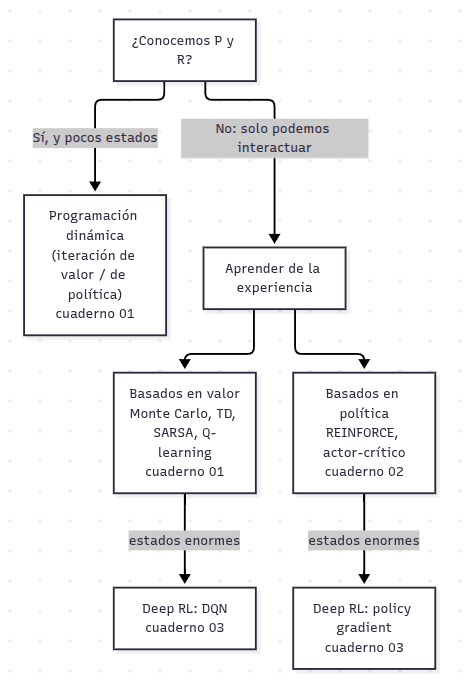

Dos ideas para llevar al siguiente cuaderno:

- Con el modelo conocido el problema se **resuelve sin interactuar** (programación dinámica): es *planificación*, el primo cercano de la búsqueda de [Introducción a la IA](../../Introduccion%20a%20la%20Inteligencia%20Artificial/04%20-%20Algoritmos%20de%20Busqueda/README.md), pero con transiciones **estocásticas** y una política como solución.
- Sin el modelo hay que **aprender por ensayo y error**, y ahí reaparece el dilema **exploración–explotación**: con una política aleatoria, solo ~1.5 % de los episodios recibe alguna recompensa. Una recompensa tan **escasa** es el rasgo que hace difícil a este entorno tan pequeño.

---
## Resumen y Puntos Clave 🎯

| Concepto | Mensaje Central |
|---|---|
| **Bucle agente–entorno** | El agente observa $s_t$, actúa $a_t$ y recibe $r_{t+1}, s_{t+1}$; **genera sus propios datos** y la señal es **evaluativa y retrasada** |
| **Retorno** | $G_t=\sum_k\gamma^k r_{t+k+1}$ con la recursión $G_t=r_{t+1}+\gamma G_{t+1}$; $\gamma$ fija un **horizonte efectivo** $\approx1/(1-\gamma)$ |
| **MDP** | $(\mathcal S,\mathcal A,P,R,\gamma)$ con la **propiedad de Markov**; fijada $\pi$ queda una cadena de Markov $(P_\pi,r_\pi)$ |
| **Episódico vs continuo** | Episódico: termina en un estado terminal; continuo: exige $\gamma<1$ para un retorno acotado ($\le r_{\max}/(1-\gamma)$) |
| **Evaluación exacta** | $\mathbf v_\pi=(I-\gamma P_\pi)^{-1}\mathbf r_\pi$ (sistema lineal; $\rho(\gamma P_\pi)<1$) |
| **Monte Carlo** | Promedia retornos simulados: sin sesgo, error $\propto1/\sqrt N$; **coincide con el cálculo exacto** dentro de unos pocos errores estándar |
| **Gymnasium** | `reset()` → `(obs, info)`; `step()` → `(obs, r, terminated, truncated, info)`; **no bootstrappear** si `terminated`; `truncated` ≠ terminal |
| **Verificación** | Nuestro MDP reproduce **exactamente** `env.unwrapped.P` de `FrozenLake-v1` (4×4 resbaladizo y determinista, 8×8) |
| **Exploración–explotación** | Con recompensa escasa, una política aleatoria casi nunca ve una recompensa: hace falta **explorar con inteligencia** |

> 🎓 **Siguiente paso:** [Funciones de valor y Q-learning](01_Funciones_de_Valor_y_Q_Learning.ipynb): las ecuaciones de **Bellman**, la **programación dinámica** (iteración de valor y de política) y los métodos que **aprenden sin conocer el modelo**: Monte Carlo, TD(0), SARSA y Q-learning.

---
### 🧠 Autoevaluación

1. Explica con tus palabras la diferencia entre la señal de un problema supervisado y la de uno de refuerzo. ¿Por qué decimos que la recompensa es *evaluativa* y *retrasada*, y qué dificultad añade el hecho de que el agente genere sus propios datos?
2. En el ejemplo del §2, el retorno $G_0$ cambia mucho al pasar de $\gamma=0$ a $\gamma=1$. Describe qué comportamiento esperarías de un agente con $\gamma=0.1$ y de otro con $\gamma=0.999$ en una tarea de ajedrez, y qué problemas prácticos tendría cada uno.
3. ¿Cuándo un estado «tiene» la propiedad de Markov? Da un ejemplo de observación que **no** la cumple y cómo la restaurarías.
4. Tu agente aprende con *bootstrapping* en un entorno que corta cada episodio a los 200 pasos. En el último paso Gymnasium devuelve `terminated=False, truncated=True`. ¿Debes poner a cero el valor del siguiente estado? Justifica.

---
<div align="center">
  <p style="font-size: 0.9em; color: #64748b;">
    © 2026 <b>Universidad Santo Tomás — Seccional Tunja</b><br>
    <i>Especialización en Ciencia de Datos | Asignatura: Machine Learning</i>
  </p>
</div>